# 00 · Neural Networks: from Logistic Regression to the MLP

A neural network is a stack of logistic-regression-like units whose **features are learned** instead of hand-designed. This notebook builds the model and its forward pass; notebook 01 shows how to train it (backpropagation).

**Contents**

1. One neuron = logistic regression
2. The limit of linear models: XOR (proof)
3. Hidden layers learn the features
4. The multilayer perceptron (MLP): notation and forward propagation
5. Why the activation must be non-linear (proof)
6. Activation functions
7. Output layer + loss = maximum likelihood
8. Universal approximation (a constructive picture)
9. The loss is no longer convex (proof)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
rng = np.random.default_rng(0)

## Notation (same as the ML notes)

| Symbol | Meaning |
|---|---|
| $m$, $n$ | number of examples, number of input features |
| $\mathbf{x}^{(i)}$, $y^{(i)}$ | $i$-th input and target; $\mathbf{X}\in\mathbb{R}^{m\times n}$ stacks the inputs as rows |
| $L$ | number of layers (hidden + output); $n_l$ = number of units in layer $l$, $n_0 = n$ |
| $\mathbf{W}^{[l]}\in\mathbb{R}^{n_{l-1}\times n_l}$, $\mathbf{b}^{[l]}\in\mathbb{R}^{1\times n_l}$ | weights and bias of layer $l$ |
| $\boldsymbol{\theta} = \{\mathbf{W}^{[l]}, \mathbf{b}^{[l]}\}_{l=1}^L$ | **all** parameters of the network |
| $\mathbf{Z}^{[l]}, \mathbf{A}^{[l]}$ | pre-activation and activation of layer $l$ (one row per example); $\mathbf{A}^{[0]} = \mathbf{X}$ |
| $g^{[l]}$ | activation function of layer $l$ (applied element-wise) |
| $J(\boldsymbol{\theta})$ | loss, $\alpha$ learning rate |

Unlike the ML notes, the bias is kept as a separate vector $\mathbf{b}$ instead of a column of ones in $\mathbf{X}$. This is the convention of every deep learning library.

## 1. One neuron = logistic regression

A **neuron** computes a weighted sum of its inputs plus a bias, then applies an **activation function** $g$:

$$
a = g(z), \qquad z = \mathbf{x}^\top\mathbf{w} + b = \sum_{j=1}^n w_jx_j + b .
$$

With $g = \sigma$ (sigmoid) and the cross-entropy loss, a single neuron **is** logistic regression (ML notes 02): $\mathbf{w}$ plays the role of $(\theta_1,\dots,\theta_n)$ and $b$ of $\theta_0$. With $g$ = identity and squared loss it is linear regression. Its decision boundary $\mathbf{x}^\top\mathbf{w} + b = 0$ is a hyperplane.

## 2. The limit of linear models: XOR

Four points with labels $y = \mathbb{1}[x_1x_2 > 0]$:

| $x_1$ | $x_2$ | $y$ |
|---|---|---|
| $+1$ | $+1$ | 1 |
| $-1$ | $-1$ | 1 |
| $+1$ | $-1$ | 0 |
| $-1$ | $+1$ | 0 |

**Claim.** No linear classifier $\hat{y} = \mathbb{1}[w_1x_1 + w_2x_2 + b > 0]$ gets all four right.

*Proof.* The two positive points need $b + w_1 + w_2 > 0$ and $b - w_1 - w_2 > 0$. Adding them gives $2b > 0$. The two negative points need $b + w_1 - w_2 \le 0$ and $b - w_1 + w_2 \le 0$. Adding them gives $2b \le 0$. Contradiction. $\blacksquare$

Logistic regression on XOR-like data therefore stays near 50 % accuracy, however long it trains.

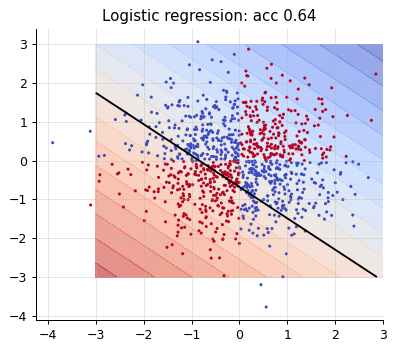

In [2]:
from sklearn.linear_model import LogisticRegression
m = 1000
X = rng.normal(size=(m, 2)); y = (X[:, 0] * X[:, 1] > 0).astype(int)
g1, g2 = np.meshgrid(np.linspace(-3, 3, 300), np.linspace(-3, 3, 300)); G = np.c_[g1.ravel(), g2.ravel()]

def plot_boundary(ax, predict_proba, title):
    P = predict_proba(G).reshape(g1.shape)
    ax.contourf(g1, g2, P, levels=20, cmap="coolwarm", alpha=0.6); ax.contour(g1, g2, P, levels=[0.5], colors="k")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=6, edgecolor="none"); ax.set_title(title)

lr = LogisticRegression().fit(X, y)
fig, ax = plt.subplots(figsize=(4.5, 4))
plot_boundary(ax, lambda A: lr.predict_proba(A)[:, 1], f"Logistic regression: acc {lr.score(X, y):.2f}")
plt.tight_layout(); plt.show()

## 3. Hidden layers learn the features

In ML notes 03 we fixed non-linear data by **adding features by hand** (e.g. $x_1x_2$ solves XOR at once). A neural network **learns** the features: a first layer of neurons computes new features $\mathbf{a}^{[1]} = g(\mathbf{x}^\top\mathbf{W}^{[1]} + \mathbf{b}^{[1]})$, and a final logistic-regression neuron classifies using them.

**XOR by hand with 2 hidden ReLU units**, $\mathrm{ReLU}(z) = \max(0,z)$. Take
$$
a_1 = \mathrm{ReLU}(x_1 + x_2), \qquad a_2 = \mathrm{ReLU}(-x_1 - x_2), \qquad z_{\text{out}} = a_1 + a_2 - 1 .
$$
Then $a_1 + a_2 = |x_1 + x_2|$, which is 2 for the positive points $(\pm1,\pm1)$ and 0 for the negative ones $(\pm1,\mp1)$. So $z_{\text{out}} = +1$ for class 1 and $-1$ for class 0. In the hidden-feature space $(a_1, a_2)$ the classes **are** linearly separable. That is the whole idea: each layer transforms the data until a linear classifier suffices.

In [3]:
X4 = np.array([[1, 1], [-1, -1], [1, -1], [-1, 1]]); y4 = np.array([1, 1, 0, 0])
relu = lambda z: np.maximum(0, z)
A1 = relu(X4 @ np.array([[1, -1], [1, -1]]))            # columns = the two hidden units
z_out = A1 @ np.array([1, 1]) - 1
print("hidden features a1, a2:\n", A1)
print("output score:", z_out, " -> predicted class:", (z_out > 0).astype(int), " true:", y4)

hidden features a1, a2:
 [[2 0]
 [0 2]
 [0 0]
 [0 0]]
output score: [ 1  1 -1 -1]  -> predicted class: [1 1 0 0]  true: [1 1 0 0]


## 4. The multilayer perceptron (MLP)

An MLP (fully connected feed-forward network) stacks $L$ layers. **Forward propagation**, for the whole batch at once:

$$
\mathbf{A}^{[0]} = \mathbf{X}, \qquad
\mathbf{Z}^{[l]} = \mathbf{A}^{[l-1]}\mathbf{W}^{[l]} + \mathbf{b}^{[l]}, \qquad
\mathbf{A}^{[l]} = g^{[l]}\big(\mathbf{Z}^{[l]}\big), \qquad l = 1,\dots,L,
$$

and the prediction is $\hat{\mathbf{Y}} = \mathbf{A}^{[L]}$. (The bias row $\mathbf{b}^{[l]}$ is added to every row: "broadcasting".)

**Shapes**: $\mathbf{A}^{[l-1]}$ is $m\times n_{l-1}$, $\mathbf{W}^{[l]}$ is $n_{l-1}\times n_l$, so $\mathbf{Z}^{[l]}$ and $\mathbf{A}^{[l]}$ are $m\times n_l$. Checking shapes is the fastest way to debug a network.

**Number of parameters**: $\sum_{l=1}^L (n_{l-1}n_l + n_l) = \sum_l (n_{l-1}+1)\,n_l$.
Example: a 784 → 128 → 10 network (Fashion-MNIST lab) has $785\cdot128 + 129\cdot10 = 101{,}770$ parameters.

The network is just a composed function $h_{\boldsymbol{\theta}}(\mathbf{x}) = g^{[L]}\big(\cdots g^{[1]}(\mathbf{x}^\top\mathbf{W}^{[1]} + \mathbf{b}^{[1]})\cdots\big)$.

In [4]:
def init_params(sizes, rng):
    """sizes = [n0, n1, ..., nL]; small random weights, zero biases."""
    return [(rng.normal(0, np.sqrt(2 / a), (a, b)), np.zeros((1, b))) for a, b in zip(sizes[:-1], sizes[1:])]

def forward(X, params, g_hidden, g_out):
    A = X
    for l, (W, b) in enumerate(params):
        Z = A @ W + b
        A = g_out(Z) if l == len(params) - 1 else g_hidden(Z)
    return A

sigmoid = lambda z: 1 / (1 + np.exp(-z))
params = init_params([2, 16, 16, 1], rng)
for l, (W, b) in enumerate(params, 1):
    print(f"layer {l}: W {W.shape}, b {b.shape}")
print("parameters:", sum(W.size + b.size for W, b in params))
print("output for 3 inputs (random, untrained net):", forward(X[:3], params, relu, sigmoid).ravel().round(3))

layer 1: W (2, 16), b (1, 16)
layer 2: W (16, 16), b (1, 16)
layer 3: W (16, 1), b (1, 1)
parameters: 337
output for 3 inputs (random, untrained net): [0.504 0.473 0.652]


## 5. Why the activation must be non-linear

**Claim.** Without non-linear activations, any number of layers collapses to a single linear layer.

*Proof.* With $g$ = identity, $\mathbf{A}^{[2]} = (\mathbf{X}\mathbf{W}^{[1]} + \mathbf{b}^{[1]})\mathbf{W}^{[2]} + \mathbf{b}^{[2]} = \mathbf{X}\underbrace{\mathbf{W}^{[1]}\mathbf{W}^{[2]}}_{\mathbf{W}'} + \underbrace{\mathbf{b}^{[1]}\mathbf{W}^{[2]} + \mathbf{b}^{[2]}}_{\mathbf{b}'}$, which is one affine layer. By induction the same holds for $L$ layers. $\blacksquare$

So a deep *linear* network is no more expressive than linear regression. The non-linearity is what gives depth its power.

## 6. Activation functions

| Name | $g(z)$ | $g'(z)$ | Notes |
|---|---|---|---|
| Sigmoid | $\sigma(z) = \frac{1}{1+e^{-z}}$ | $\sigma(z)(1-\sigma(z)) \le \frac14$ | output layer for binary tasks; **saturates** → vanishing gradients in hidden layers |
| tanh | $\frac{e^z - e^{-z}}{e^z + e^{-z}} = 2\sigma(2z) - 1$ | $1 - \tanh^2(z) \le 1$ | zero-centred; still saturates; used in RNNs |
| ReLU | $\max(0, z)$ | $\mathbb{1}[z > 0]$ | default for hidden layers: cheap, no saturation for $z>0$; units can "die" (always $z<0$) |
| Leaky ReLU | $\max(\beta z, z)$, $\beta\approx0.01$ | $1$ or $\beta$ | never fully dead |
| GELU | $z\,\Phi(z)$ | smooth | used in transformers |

*Proof that $\tanh(z) = 2\sigma(2z) - 1$:* $2\sigma(2z) - 1 = \frac{2}{1+e^{-2z}} - 1 = \frac{1-e^{-2z}}{1+e^{-2z}}$; multiply numerator and denominator by $e^z$ to get $\frac{e^z - e^{-z}}{e^z + e^{-z}}$.

**Saturation.** Where the curve is flat ($|z|$ large for sigmoid/tanh), $g'(z)\approx0$. In backpropagation every layer multiplies the gradient by $g'$ (notebook 01), so flat regions stop learning. ReLU's derivative is exactly 1 for $z>0$.

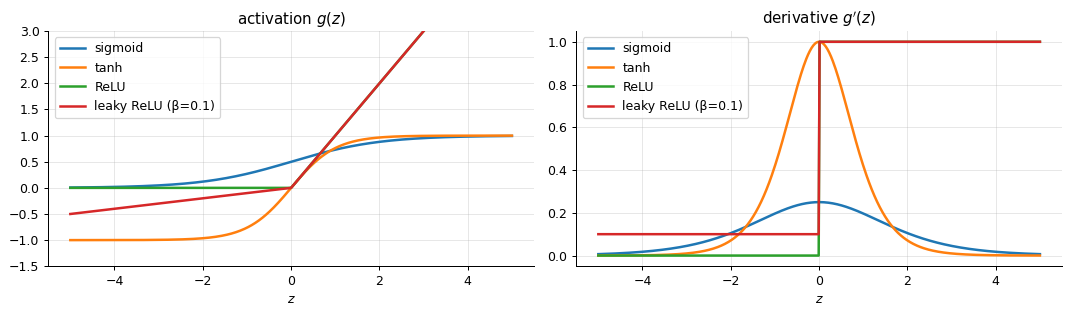

In [5]:
z = np.linspace(-5, 5, 500)
acts = {"sigmoid": (sigmoid(z), sigmoid(z) * (1 - sigmoid(z))),
        "tanh": (np.tanh(z), 1 - np.tanh(z) ** 2),
        "ReLU": (relu(z), (z > 0).astype(float)),
        "leaky ReLU (β=0.1)": (np.maximum(0.1 * z, z), np.where(z > 0, 1, 0.1))}
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for name, (f, d) in acts.items():
    axes[0].plot(z, f, lw=2, label=name); axes[1].plot(z, d, lw=2, label=name)
axes[0].set_title("activation $g(z)$"); axes[1].set_title("derivative $g'(z)$"); axes[0].set_ylim(-1.5, 3)
for ax in axes: ax.legend(); ax.set_xlabel("$z$")
plt.tight_layout(); plt.show()

## 7. Output layer + loss = maximum likelihood

The hidden layers are generic. The **output layer and loss are chosen by the task**, with exactly the reasoning of the ML notes: pick a distribution for $y$ given the network's output, and minimise the negative log-likelihood.

| Task | Output layer $g^{[L]}$ | Distribution of $y\mid\mathbf{x}$ | Loss $J(\boldsymbol{\theta})$ | PyTorch |
|---|---|---|---|---|
| Regression | identity | Gaussian | MSE $\frac{1}{m}\sum(\hat{y}-y)^2$ | `MSELoss` |
| Binary classification | sigmoid, 1 unit | Bernoulli | binary cross-entropy | `BCEWithLogitsLoss` |
| $K$ classes | softmax, $K$ units | categorical | categorical cross-entropy | `CrossEntropyLoss` |
| $K$ independent labels (multi-label) | $K$ sigmoids | $K$ Bernoullis | sum of BCEs | `BCEWithLogitsLoss` |

The derivations are ML notes 01 (Gaussian → MSE), 02 (Bernoulli → BCE) and 04 (categorical → cross-entropy). A neural network is simply linear/logistic/softmax regression **on learned features** $\mathbf{A}^{[L-1]}$.

**Work with logits.** Libraries take the pre-activation $z$ (the *logit*) and fuse the sigmoid/softmax into the loss, because it is numerically stable. For BCE with $p = \sigma(z)$:
$$
-\big[y\log\sigma(z) + (1-y)\log(1-\sigma(z))\big] = \log(1+e^{z}) - yz = \max(z, 0) - yz + \log\big(1 + e^{-|z|}\big),
$$
and the last form never overflows. (*Proof of the first equality:* $\log\sigma(z) = -\log(1+e^{-z})$ and $\log(1-\sigma(z)) = -z - \log(1+e^{-z})$, so the bracket is $-\log(1+e^{-z}) - (1-y)z$, and $\log(1+e^{-z}) + z = \log(1+e^{z})$.) The same applies to softmax: `CrossEntropyLoss` takes raw logits; `NLLLoss` needs `log_softmax` first.

## 8. Universal approximation (a constructive picture)

**Theorem (Cybenko 1989; Hornik 1991; Leshno et al. 1993).** A network with **one** hidden layer and any non-polynomial activation can approximate any continuous function on a bounded domain to any accuracy, given enough hidden units.

**Why, for ReLU in 1D.** A one-hidden-layer ReLU network computes $h(x) = c + \sum_k v_k\,\mathrm{ReLU}(x - t_k)$, a **piecewise-linear** function with kinks at the $t_k$. Each unit changes the slope by $v_k$ at $x = t_k$. So to interpolate a target $f$ at knots $t_0 < t_1 < \dots < t_K$, set $c = f(t_0)$, the first slope $v_0 = s_0$, and $v_k = s_k - s_{k-1}$, where $s_k$ is the slope of the segment $[t_k, t_{k+1}]$. More units = finer knots = smaller error. The cell below builds such a network **by hand, without training**.

Caveats: the theorem says such weights *exist*. It says nothing about how many units are needed (possibly exponentially many), or whether gradient descent finds them, or how well they generalise. In practice **depth** helps: deep networks can represent many functions with far fewer units than shallow ones (compositions create exponentially many linear pieces).

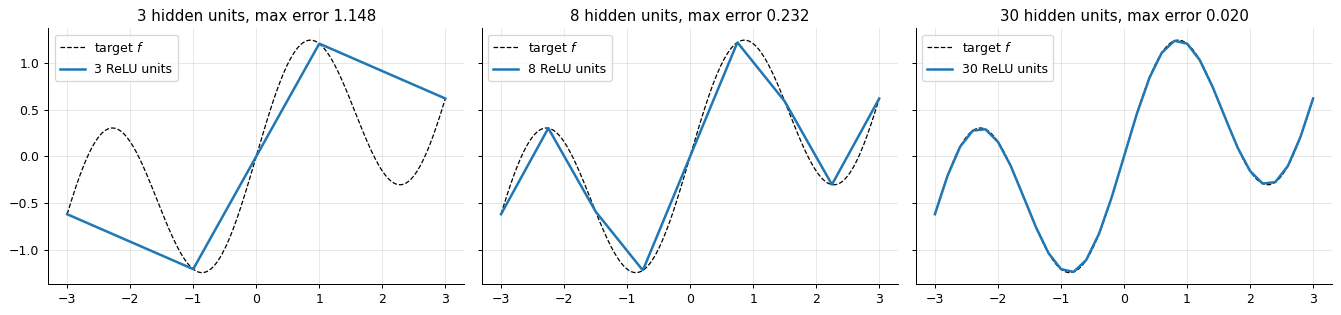

In [6]:
f = lambda x: np.sin(2 * x) + 0.3 * x
xs = np.linspace(-3, 3, 600)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6), sharey=True)
for ax, K in zip(axes, [3, 8, 30]):
    t = np.linspace(-3, 3, K + 1)                       # knots
    s = np.diff(f(t)) / np.diff(t)                      # slopes of each segment
    v = np.r_[s[0], np.diff(s)]                         # slope changes = output weights
    h = f(t[0]) + sum(vk * relu(xs - tk) for vk, tk in zip(v, t[:-1]))
    ax.plot(xs, f(xs), "k--", lw=1, label="target $f$")
    ax.plot(xs, h, lw=2, label=f"{K} ReLU units")
    ax.set_title(f"{K} hidden units, max error {np.max(np.abs(h - f(xs))):.3f}"); ax.legend()
plt.tight_layout(); plt.show()

**A trained MLP on the XOR data.** Trained with backpropagation (notebook 01, here via scikit-learn). Each hidden unit learns a line, and the output combines them into a non-linear boundary.

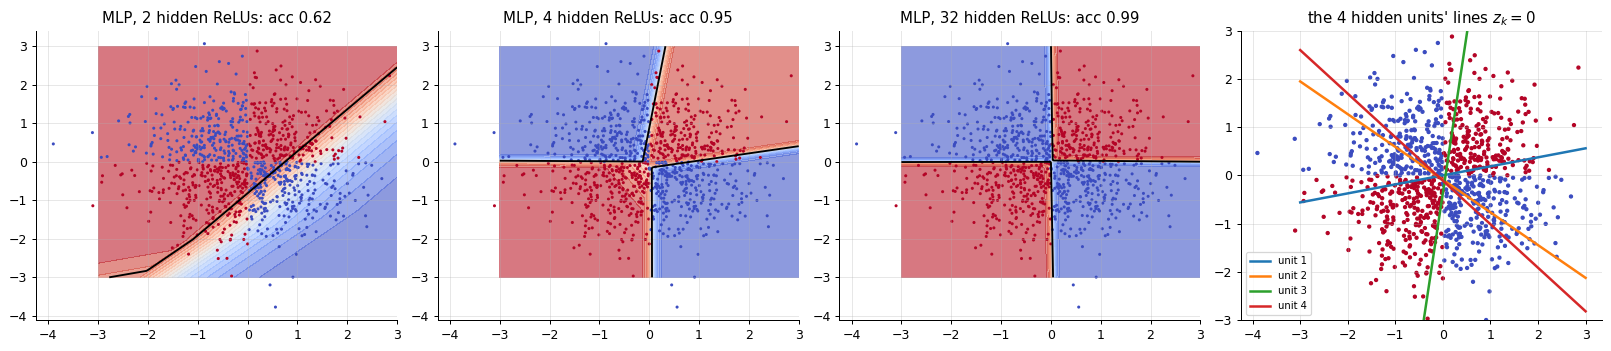

In [7]:
from sklearn.neural_network import MLPClassifier
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, h in zip(axes[:3], [2, 4, 32]):
    mlp = MLPClassifier(hidden_layer_sizes=(h,), activation="relu", max_iter=3000, random_state=1).fit(X, y)
    plot_boundary(ax, lambda A: mlp.predict_proba(A)[:, 1], f"MLP, {h} hidden ReLUs: acc {mlp.score(X, y):.2f}")
mlp4 = MLPClassifier(hidden_layer_sizes=(4,), activation="relu", max_iter=3000, random_state=1).fit(X, y)
W1, b1 = mlp4.coefs_[0], mlp4.intercepts_[0]
axes[3].scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=6)
for k in range(4):   # line where hidden unit k switches on: x1*W[0,k] + x2*W[1,k] + b_k = 0
    axes[3].plot(g1[0], -(W1[0, k] * g1[0] + b1[k]) / W1[1, k], lw=2, label=f"unit {k+1}")
axes[3].set_ylim(-3, 3); axes[3].legend(fontsize=8); axes[3].set_title("the 4 hidden units' lines $z_k=0$")
plt.tight_layout(); plt.show()

Two hidden units are enough for the four XOR corner points (section 3), but not for this quadrant-shaped cloud: the boundary needs two full lines through the origin, and with 2 ReLUs gradient descent finds only a partial solution. With 4 units each quadrant edge gets its own unit (right panel), and more units make the boundary sharper.

## 9. The loss is no longer convex

Linear, logistic and softmax regression have convex losses (ML notes). Neural networks do not.

**Proof (hidden-unit symmetry).** Swap hidden units $j$ and $k$ of a layer: swap columns $j,k$ of $\mathbf{W}^{[l]}$ and entries $j,k$ of $\mathbf{b}^{[l]}$, and rows $j,k$ of $\mathbf{W}^{[l+1]}$. The network computes exactly the same function, so if $\boldsymbol{\theta}^*$ is a minimiser, so is the swapped $\boldsymbol{\theta}'$. If $J$ were convex, the midpoint $\frac12(\boldsymbol{\theta}^*+\boldsymbol{\theta}')$ would also be a minimiser (a convex function is $\le$ the average of its values at the endpoints). But at the midpoint units $j$ and $k$ have **identical** weights, so they compute the same feature, and the network has lost one unit of capacity. Generically this raises the loss. So $J$ is not convex. $\blacksquare$

Consequences:
- There are many (equivalent) minima, plus saddle points and flat regions.
- The result depends on the **initialisation** and on the optimiser (notebooks 01–02).
- In practice, for large networks most local minima found by SGD are about as good as each other; the harder problems are saddle points, plateaus and bad conditioning.

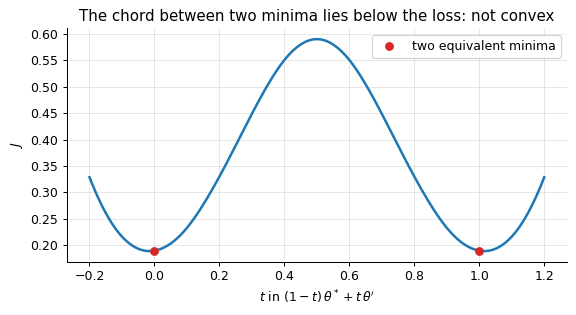

In [8]:
# Loss along the straight line between a trained network and its hidden-unit-swapped copy
import copy
Xt, yt = X[:400], y[:400]
net = MLPClassifier(hidden_layer_sizes=(4,), activation="relu", max_iter=5000, random_state=1).fit(Xt, yt)
W1, W2 = net.coefs_; b1, b2 = net.intercepts_
perm = [1, 0, 2, 3]
theta_a = [W1, b1, W2, b2]
theta_b = [W1[:, perm], b1[perm], W2[perm, :], b2]

def bce_at(theta):
    W1_, b1_, W2_, b2_ = theta
    p = sigmoid(relu(Xt @ W1_ + b1_) @ W2_ + b2_).ravel()
    return -np.mean(yt * np.log(p + 1e-12) + (1 - yt) * np.log(1 - p + 1e-12))

ts = np.linspace(-0.2, 1.2, 141)
loss = [bce_at([(1 - t) * a + t * b for a, b in zip(theta_a, theta_b)]) for t in ts]
plt.figure(figsize=(6.5, 3.6)); plt.plot(ts, loss, lw=2)
plt.scatter([0, 1], [bce_at(theta_a), bce_at(theta_b)], color="C3", zorder=3, label="two equivalent minima")
plt.xlabel(r"$t$ in $(1-t)\,\theta^* + t\,\theta'$"); plt.ylabel(r"$J$"); plt.legend()
plt.title("The chord between two minima lies below the loss: not convex"); plt.tight_layout(); plt.show()

## Summary

- A neuron is $g(\mathbf{x}^\top\mathbf{w}+b)$; one sigmoid neuron is logistic regression.
- Linear models can't solve XOR (proof); a hidden layer learns features that make the problem linearly separable.
- MLP forward pass: $\mathbf{Z}^{[l]} = \mathbf{A}^{[l-1]}\mathbf{W}^{[l]} + \mathbf{b}^{[l]}$, $\mathbf{A}^{[l]} = g^{[l]}(\mathbf{Z}^{[l]})$; parameters $\boldsymbol{\theta} = \{\mathbf{W}^{[l]},\mathbf{b}^{[l]}\}$.
- Non-linear activations are essential (linear layers collapse). ReLU is the default in hidden layers; sigmoid/softmax go in the output layer.
- The output layer and loss come from maximum likelihood, as in the ML notes; pass logits to fused, stable losses.
- One hidden layer is a universal approximator, but depth is more efficient.
- The loss is non-convex (hidden-unit symmetry), so initialisation and optimisation matter.